# **Final Project Notebook**

### Zoe Kirkman & Madison Engebose

## Research Question
How do different features relate to burnout in technical workers that use AI for thier jobs?

## Hypothesis
1. Different remote work types have different levels of burnout.
2. Employees who spend more hours with AI assistance will experience higher burnout. 
3. More weekly AI upskilling hours are associated with lower burnout
4. High attrition risk increases burnout
5. Employees with higher fear of AI replacement have higher burnout scores. 

## Dataset
The dataset we are using looks at features related to job type and function, AI use within the job, and employee feelings about AI with respect to their jobs. The dataset was created synthetically using the patterns described in the following studies: Microsoft's 2025 Work Trend Index, Stack Overflow Developer Survey 2024-2025, Gallup Workplace Burnout Studies, LinkedIn Workforce Confidence Reports, and World Economic Forum Future of Jobs Report 2025.   
Why dataset was created
Who created it
Explanation of features and target variables 
references to dataset


| Feature | Description | 
|---|---|
| `employee_id` | Unique identifier (dropped for modeling) |
| `job_role` | e.g., Data Analyst, Prompt Engineer |
| `years_experience` | Total years of work experience |
| `education_level` | Self-taught → Bachelor → Master → PhD |
| `country` | Country of employment |
| `industry` | Industry sector |
| `company_size` | Startup → Small → Mid → Large |
| `remote_work_type` | On-site / Hybrid / Fully Remote |
| `team_size` | Number of teammates |
| `salary_usd_k` | Annual salary in USD thousands |
| `primary_ai_tool` | Main AI tool used |
| `ai_tools_used_per_day` | Count of AI tools used daily |
| `hours_with_ai_assistance_daily`  | Daily hours using AI assistance |
| `ai_replaces_my_tasks_pct` | % of tasks the employee feels AI replaces |
| `ai_adoption_stage` | Experimenting → Integrating → Optimizing |
| `weekly_ai_upskilling_hrs`  | Hours/week spent learning AI skills |
| `productivity_score` | Self-reported productivity (0–100) |
| `burnout_score` | Self-reported burnout (0–100, higher = worse) |
| `job_satisfaction_1_5`| Job satisfaction on 1–5 scale |
| `fear_of_ai_replacement` | Low / Medium / High |
| `attrition_risk` | Low / Medium / High |

## Imports and Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress, kruskal
from sklearn.metrics import mean_squared_error
import numpy as np
import statsmodels.api as sm

In [7]:
df = pd.read_csv('ai_worker_burnout_attrition_2026.csv')
df.head(10)

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
5,EMP0006,Data Analyst,12,Self-taught,Germany,Healthtech,Large (1000-5000),On-site,19,106,...,5,5.7,23,Optimizing,6.7,66,61,3.5,Medium,Low
6,EMP0007,AI Ethics Officer,12,PhD,USA,Gaming,Enterprise (5000+),Fully Remote,46,154,...,1,2.7,45,Optimizing,8.1,54,33,3.5,High,Low
7,EMP0008,Data Scientist,19,Bootcamp,Singapore,Consulting,Enterprise (5000+),Hybrid,44,54,...,7,4.7,46,Optimizing,9.1,43,57,2.9,Low,Medium
8,EMP0009,Data Analyst,6,Master,Germany,Fintech,Mid (200-1000),Hybrid,42,55,...,7,2.8,56,Experimenting,8.1,69,52,2.8,Low,Medium
9,EMP0010,Prompt Engineer,2,Bachelor,Netherlands,Gaming,Large (1000-5000),On-site,15,61,...,5,1.8,8,Optimizing,9.7,64,27,3.8,Medium,Low


In [8]:
df.dtypes

employee_id                        object
job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object

In [9]:
nominal_cats = [
    "job_role", "education_level", "country",
    "industry", "company_size", "remote_work_type", "primary_ai_tool",
]
for col in nominal_cats:
    df[col] = df[col].astype("category")

In [10]:
df["fear_of_ai_replacement"] = pd.Categorical(
    df["fear_of_ai_replacement"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
df["attrition_risk"] = pd.Categorical(
    df["attrition_risk"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
df["ai_adoption_stage"] = pd.Categorical(
    df["ai_adoption_stage"],
    categories=["Experimenting", "Integrating", "Optimizing", "AI-First"],
    ordered=True,
)

In [11]:
df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [12]:
df.dtypes

employee_id                         object
job_role                          category
years_experience                     int64
education_level                   category
country                           category
industry                          category
company_size                      category
remote_work_type                  category
team_size                            int64
salary_usd_k                         int64
primary_ai_tool                   category
ai_tools_used_per_day                int64
hours_with_ai_assistance_daily     float64
ai_replaces_my_tasks_pct             int64
ai_adoption_stage                 category
weekly_ai_upskilling_hrs           float64
productivity_score                   int64
burnout_score                        int64
job_satisfaction_1_5               float64
fear_of_ai_replacement            category
attrition_risk                    category
dtype: object

## Visualizations

### Correlation Heatmap

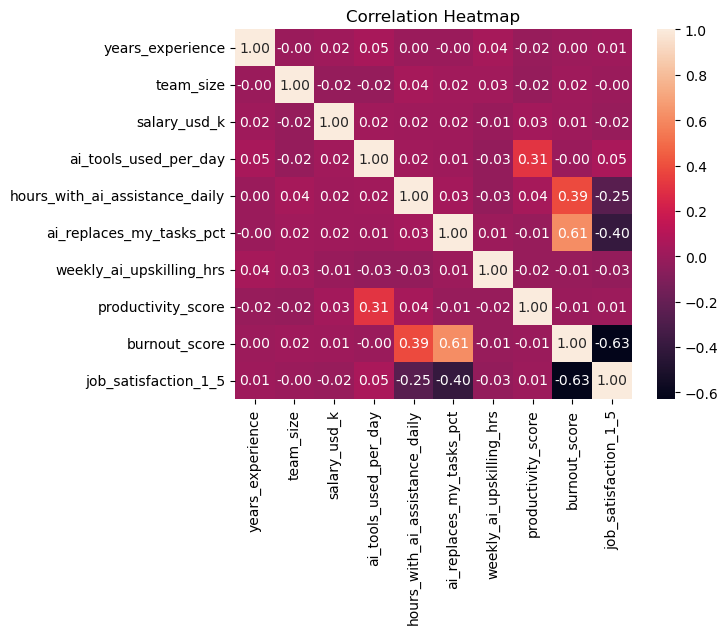

In [26]:
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### AI Replacing Tasks vs Burnout

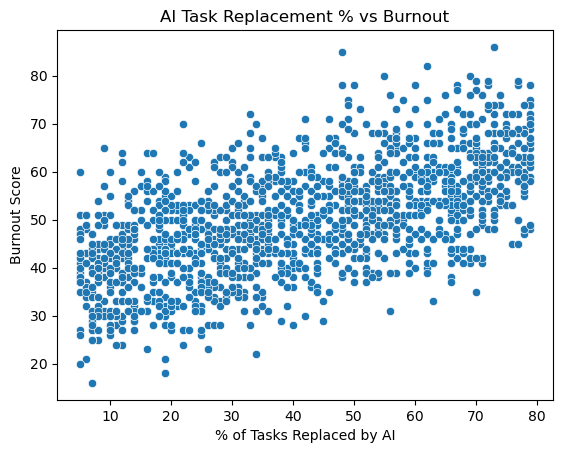

In [14]:
sns.scatterplot(x="ai_replaces_my_tasks_pct", y="burnout_score", data=df)
plt.title("AI Task Replacement % vs Burnout")
plt.xlabel("% of Tasks Replaced by AI")
plt.ylabel("Burnout Score")
plt.show()

### Daily AI Hours vs Burnout

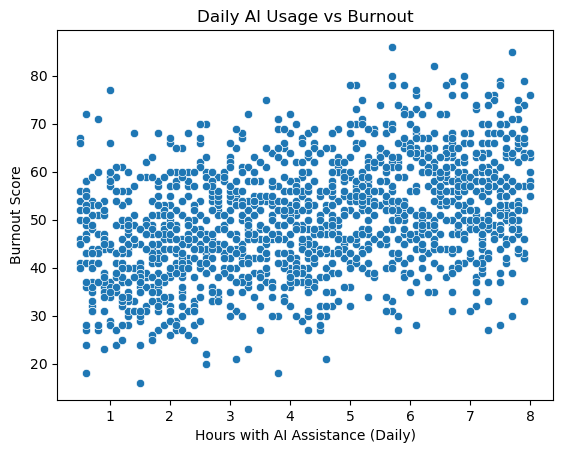

In [40]:
sns.scatterplot(x="hours_with_ai_assistance_daily", y="burnout_score", data=df)
plt.title("Daily AI Usage vs Burnout")
plt.xlabel("Hours with AI Assistance (Daily)")
plt.ylabel("Burnout Score")
plt.show()

### AI Upskilling vs Burnout

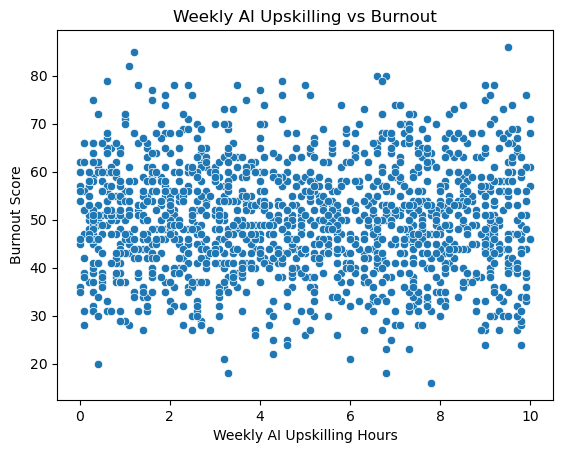

In [16]:
sns.scatterplot(x="weekly_ai_upskilling_hrs", y="burnout_score", data=df)
plt.title("Weekly AI Upskilling vs Burnout")
plt.xlabel("Weekly AI Upskilling Hours")
plt.ylabel("Burnout Score")
plt.show()

### Productivity vs Burnout

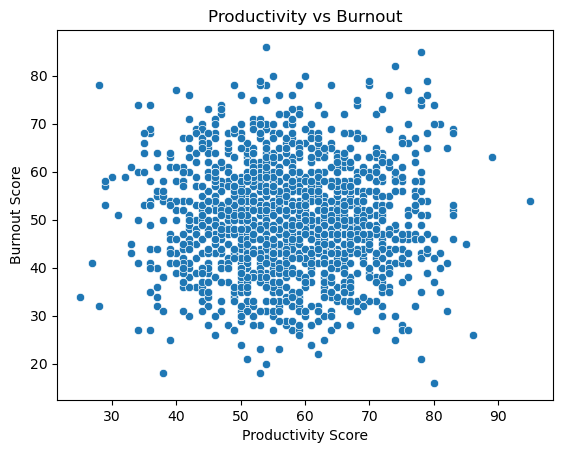

In [43]:
sns.scatterplot(x="productivity_score", y="burnout_score", data=df)
plt.title("Productivity vs Burnout")
plt.xlabel("Productivity Score")
plt.ylabel("Burnout Score")
plt.show()

### Job Satisfaction vs Burnout

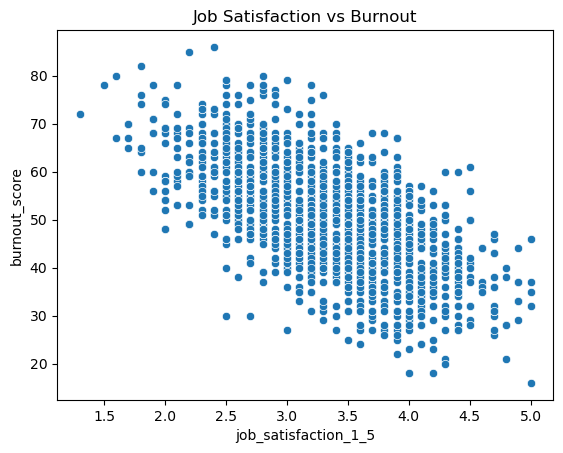

In [44]:
sns.scatterplot(x="job_satisfaction_1_5", y="burnout_score", data=df)
plt.title("Job Satisfaction vs Burnout")
plt.show()

### Burnout by Remote Work Type

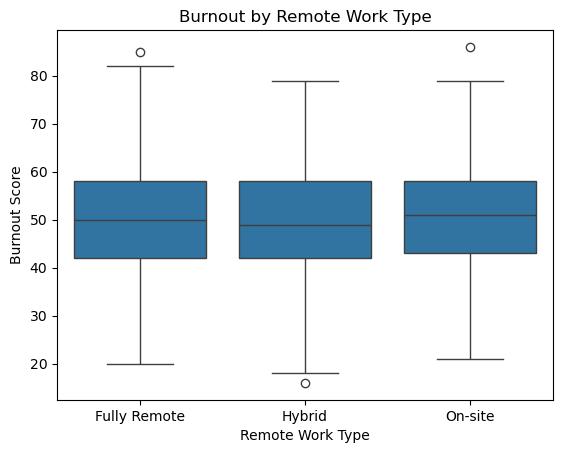

In [13]:
sns.boxplot(x="remote_work_type", y="burnout_score", data=df)
plt.title("Burnout by Remote Work Type")
plt.xlabel("Remote Work Type")
plt.ylabel("Burnout Score")
plt.show()

### Fear of AI Replacement vs Burnout

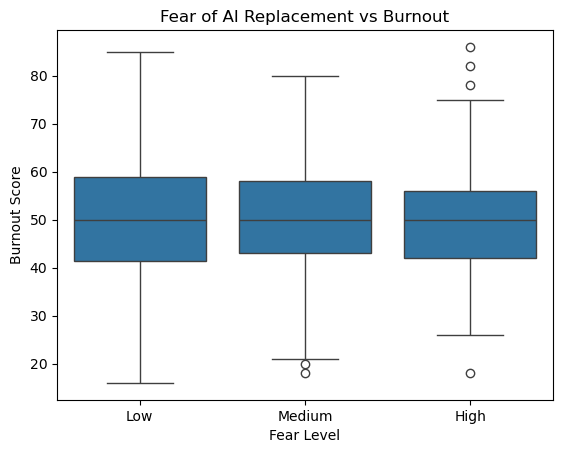

In [17]:
sns.boxplot(x="fear_of_ai_replacement", y="burnout_score", data=df)
plt.title("Fear of AI Replacement vs Burnout")
plt.xlabel("Fear Level")
plt.ylabel("Burnout Score")
plt.show()

### Burnout vs Attrition Risk

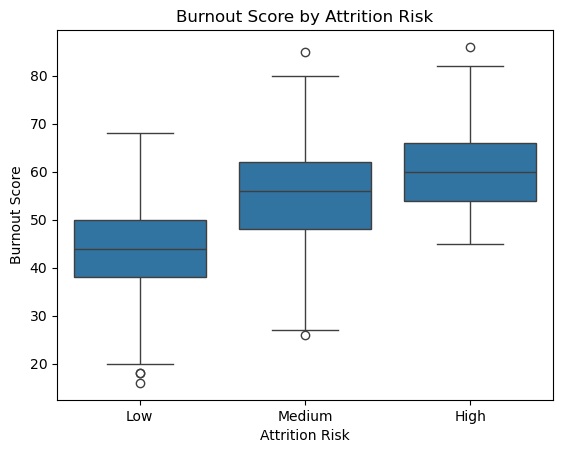

In [18]:
sns.boxplot(x="attrition_risk", y="burnout_score", data=df)
plt.title("Burnout Score by Attrition Risk")
plt.xlabel("Attrition Risk")
plt.ylabel("Burnout Score")
plt.show()

### Productivity vs Attrition Risk

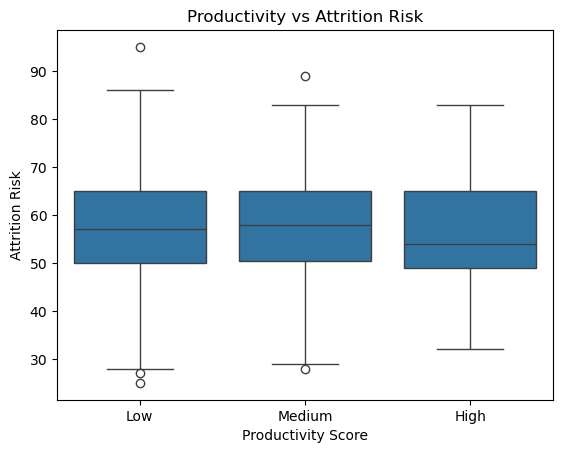

In [20]:
sns.boxplot(x="attrition_risk", y="productivity_score", data=df)
plt.title("Productivity vs Attrition Risk")
plt.xlabel("Productivity Score")
plt.ylabel("Attrition Risk")
plt.show()

## Statistical Testing

In [45]:
y_col = 'burnout_score'

numerical_predictors = ['years_experience', 'team_size', 'salary_usd_k',
                        'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
                        'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
                        'productivity_score', 'job_satisfaction_1_5']

categorical_predictors = ['job_role', 'education_level', 'country', 'industry',
                          'company_size', 'remote_work_type', 'primary_ai_tool',
                          'ai_adoption_stage', 'fear_of_ai_replacement', 'attrition_risk']

alpha = 0.05

### Pearson Correlation with Bonferonni Correction

In [55]:
results_linreg = []
total_tests = len(numerical_predictors) + len(categorical_predictors)
bonf_alpha = alpha / total_tests

for x_col in numerical_predictors:
    tmp = df[[y_col, x_col]].dropna()
    lr = linregress(tmp[x_col], tmp[y_col])

    results_linreg.append({
        "predictor": x_col,
        "response": y_col,
        "test": "linregress (Pearson corr)",
        "statistic": lr.rvalue,
        "p_value": lr.pvalue,
        "bonferroni_alpha": bonf_alpha,
        "n": len(tmp),
        "significant": lr.pvalue < bonf_alpha,
    })

results_linreg

[{'predictor': 'years_experience',
  'response': 'burnout_score',
  'test': 'linregress (Pearson corr)',
  'statistic': np.float64(0.004534171615242385),
  'p_value': np.float64(0.8607164562337624),
  'bonferroni_alpha': 0.002631578947368421,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'team_size',
  'response': 'burnout_score',
  'test': 'linregress (Pearson corr)',
  'statistic': np.float64(0.017170791880538938),
  'p_value': np.float64(0.5063597918443248),
  'bonferroni_alpha': 0.002631578947368421,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'salary_usd_k',
  'response': 'burnout_score',
  'test': 'linregress (Pearson corr)',
  'statistic': np.float64(0.013117776396078664),
  'p_value': np.float64(0.6117005030611817),
  'bonferroni_alpha': 0.002631578947368421,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'ai_tools_used_per_day',
  'response': 'burnout_score',
  'test': 'linregress (Pearson corr)',
  'statistic': np.float64(-0.00333329610406649

### Kruskal Wallis with Bonferroni Correlation

In [59]:
results_kruskal = []
total_tests = len(numerical_predictors) + len(categorical_predictors)
bonf_alpha = alpha / total_tests

for x_col in categorical_predictors:
    tmp = df[[y_col, x_col]].dropna()

    samples_by_group = []
    for value in set(tmp[x_col]):
        mask = tmp[x_col] == value
        samples_by_group.append(tmp[y_col][mask])

    stat, p = kruskal(*samples_by_group)

    results_kruskal.append({
        "predictor": x_col,
        "response": y_col,
        "test": "Kruskal-Wallis",
        "statistic": stat,
        "p_value": p,
        "bonferroni_alpha": bonf_alpha,
        "n": len(tmp),
        "significant": p < bonf_alpha,
    })

results_kruskal

[{'predictor': 'job_role',
  'response': 'burnout_score',
  'test': 'Kruskal-Wallis',
  'statistic': np.float64(12.46197792276874),
  'p_value': np.float64(0.3299376086430252),
  'bonferroni_alpha': 0.002631578947368421,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'education_level',
  'response': 'burnout_score',
  'test': 'Kruskal-Wallis',
  'statistic': np.float64(11.128033480236818),
  'p_value': np.float64(0.02516215958927435),
  'bonferroni_alpha': 0.002631578947368421,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'country',
  'response': 'burnout_score',
  'test': 'Kruskal-Wallis',
  'statistic': np.float64(10.875885121026199),
  'p_value': np.float64(0.28431245688269685),
  'bonferroni_alpha': 0.002631578947368421,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'industry',
  'response': 'burnout_score',
  'test': 'Kruskal-Wallis',
  'statistic': np.float64(3.273637949735108),
  'p_value': np.float64(0.9524511883399044),
  'bonferroni_alpha': 0.

### Results

**Bonferroni-corrected α = 0.05 / 19 ≈ 0.0026**

| Predictor | Test | Statistic (r or H) | p-value | Significant? |
|---|---|---|---|---|
| years_experience | Pearson (linregress) | 0.0045 | 0.8607 | No |
| team_size | Pearson (linregress) | 0.0172 | 0.5064 | No |
| salary_usd_k | Pearson (linregress) | 0.0131 | 0.6117 | No |
| ai_tools_used_per_day | Pearson (linregress) | -0.0033 | 0.8974 | No |
| hours_with_ai_assistance_daily | Pearson (linregress) | 0.3856 | 2.31e-54 | **Yes** |
| ai_replaces_my_tasks_pct | Pearson (linregress) | 0.6134 | 9.99e-156 | **Yes** |
| weekly_ai_upskilling_hrs | Pearson (linregress) | -0.0149 | 0.5650 | No |
| productivity_score | Pearson (linregress) | -0.0053 | 0.8368 | No |
| job_satisfaction_1_5 | Pearson (linregress) | -0.6293 | 3.04e-166 | **Yes** |
| job_role | Kruskal-Wallis | 12.462 | 0.3299 | No |
| education_level | Kruskal-Wallis | 11.128 | 0.0252 | No |
| country | Kruskal-Wallis | 10.876 | 0.2843 | No |
| industry | Kruskal-Wallis | 3.274 | 0.9525 | No |
| company_size | Kruskal-Wallis | 0.594 | 0.9638 | No |
| remote_work_type | Kruskal-Wallis | 1.586 | 0.4525 | No |
| primary_ai_tool | Kruskal-Wallis | 14.139 | 0.0488 | No |
| ai_adoption_stage | Kruskal-Wallis | 1.325 | 0.7232 | No |
| fear_of_ai_replacement | Kruskal-Wallis | 1.622 | 0.4444 | No |
| attrition_risk | Kruskal-Wallis | 420.194 | 5.70e-92 | **Yes** |

## Linear Regression Models

### sklearn

In [25]:
regression_model = LinearRegression()
independent_cols = pd.DataFrame(df.select_dtypes(include="number"))
independent_cols = independent_cols.drop("burnout_score", axis =1)
y = df["burnout_score"]

results = regression_model.fit(independent_cols, y)
for i in range(len(independent_cols.columns)):
    print(f"{independent_cols.columns[i]}: {results.coef_[i]:.4f}")
    print(f"p-value: {linregress(independent_cols.iloc[:, i], y).pvalue:.4f}")
    print(f"R-squared: {linregress(independent_cols.iloc[:, i], y).rvalue**2:.4f}\n")
    


years_experience: 0.0222
p-value: 0.8607
R-squared: 0.0000

team_size: -0.0053
p-value: 0.5064
R-squared: 0.0003

salary_usd_k: -0.0012
p-value: 0.6117
R-squared: 0.0002

ai_tools_used_per_day: 0.0523
p-value: 0.8974
R-squared: 0.0000

hours_with_ai_assistance_daily: 1.4538
p-value: 0.0000
R-squared: 0.1487

ai_replaces_my_tasks_pct: 0.2387
p-value: 0.0000
R-squared: 0.3762

weekly_ai_upskilling_hrs: -0.0797
p-value: 0.5650
R-squared: 0.0002

productivity_score: -0.0122
p-value: 0.8368
R-squared: 0.0000

job_satisfaction_1_5: -6.8282
p-value: 0.0000
R-squared: 0.3961



**Based on Sklern:**

Statistically Significant Variables:

- hours_with_ai_assistance_daily
- ai_replaces_my_tasks_pct
- job_satisfaction_1_5

### Statsmodel API

This model uses all numerical values without any categorical variables being encoded

In [27]:
X = sm.add_constant(independent_cols)
linear_model = sm.OLS(y, X).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     272.4
Date:                Sat, 18 Apr 2026   Prob (F-statistic):          3.33e-307
Time:                        17:57:40   Log-Likelihood:                -5053.7
No. Observations:                1500   AIC:                         1.013e+04
Df Residuals:                    1490   BIC:                         1.018e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

**Based on Statsmodel API:**

Statistically Significant Variables:

- hours_with_ai_assistance_daily
- ai_replaces_my_tasks_pct
- job_satisfaction_1_5

### The following linear regression model only has the predictors that are statistically significant and it has the same ajusted R-squared value so the other variables were not helpful. 
This model uses hours_with_ai_assistance, ai_replaces_my_tasks_pct, job_satisfaction_1_5 as predictors 

In [38]:
significant_predictors = independent_cols.columns[linear_model.pvalues[1:] < 0.05]
X = sm.add_constant(independent_cols[significant_predictors])
refined_model = sm.OLS(y, X).fit()
print(refined_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     817.8
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          1.04e-314
Time:                        22:43:46   Log-Likelihood:                -5055.2
No. Observations:                1500   AIC:                         1.012e+04
Df Residuals:                    1496   BIC:                         1.014e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

### One Hot Encoding

Using one hot encoding to add categorical variables to be used in the linear regression model. Including education_level, remote_work_type, fear_of_ai_replacement, and attrition_risk

In [28]:
# One hot encoding education level 
df["formal_education"] = df["education_level"].apply(lambda x: 1 if x in ["Bachelor", "Masters", "PhD"] else 0)
df["masters_phd"] = df["education_level"].apply(lambda x: 1 if x in ["Masters", "PhD"] else 0)

# Remote work type encoding
df["is_hybrid"] = df["remote_work_type"].apply(lambda x: 1 if x == "Hybrid" else 0)
df["is_remote"] = df["remote_work_type"].apply(lambda x: 1 if x == "Remote" else 0)
df["is_on_site"] = df["remote_work_type"].apply(lambda x: 1 if x == "On Site" else 0)

# Fear of AI Replacement encoding
df["fear_low"] = df["fear_of_ai_replacement"].apply(lambda x: 1 if x == "Low" else 0)
df["fear_medium"] = df["fear_of_ai_replacement"].apply(lambda x: 1 if x == "Medium" else 0)
df["fear_high"] = df["fear_of_ai_replacement"].apply(lambda x: 1 if x == "High" else 0)

# Attrition risk encoding
df["attrition_low"] = df["attrition_risk"].apply(lambda x: 1 if x == "Low" else 0)
df["attrition_medium"] = df["attrition_risk"].apply(lambda x: 1 if x == "Medium" else 0)
df["attrition_high"] = df["attrition_risk"].apply(lambda x: 1 if x == "High" else 0)

df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,masters_phd,is_hybrid,is_remote,is_on_site,fear_low,fear_medium,fear_high,attrition_low,attrition_medium,attrition_high
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0,0,0,1,0,0,0,1,0
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,0,1,0,0,0,1,0,0,1,0
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,1,1,0,0,0,0,1,0,1,0
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,0,0,0,0,1,0,0,0,1,0
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,0,0,0,0,0,1,0,0,1,0


### Regression Using All Variables with One Hot Encoding

In [29]:
new_numerical = pd.DataFrame(df.select_dtypes(include="number"))
new_numerical = new_numerical.drop("burnout_score", axis =1)
X = sm.add_constant(new_numerical)
one_hot_encoding_model = sm.OLS(y, X).fit()
print(one_hot_encoding_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     175.8
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:59:40   Log-Likelihood:                -4985.6
No. Observations:                1500   AIC:                         1.001e+04
Df Residuals:                    1483   BIC:                         1.010e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

Statistically Significant Variables:

- hours_with_ai_assistance_daily
- ai_replaces_my_tasks_pct
- job_satisfaction_1_5
- is_remote
- is_on_site
- fear_low
- fear_medium
- fear_high
- attrition_low
- attrition_medium
- attrition_high

### Using Only Significant Variables

In [50]:
significant_predictors = new_numerical.columns[one_hot_encoding_model.pvalues[1:] < 0.05]
X = sm.add_constant(new_numerical[significant_predictors])
new_refined_model = sm.OLS(y, X).fit()
print(new_refined_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     401.5
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:06:32   Log-Likelihood:                -4989.0
No. Observations:                1500   AIC:                             9994.
Df Residuals:                    1492   BIC:                         1.004e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## Results Analysis

The regression model achieved an R squared of about 0.65 on the full dataset, meaning it explains roughly 65% of the variance in burnout scores.The most statistically significant predictors were:

- hours_with_ai_assistance_daily
- ai_replaces_my_tasks_pct
- job_satisfaction_1_5
- productivity_score

This supports our regression hypothesis. More AI-intensive work hours and higher task-replacement rates are positively associated with burnout, even after controlling for satisfaction and productivity.

This dataset was synthetic so one major limitation of this analysis is that it may not generalize to real-world populations. 

**Future work and lessons learned still needed**